# Spatio-temporal registration of plant point clouds — hands-on demo

Paper: **N. Chebrolu, F. Magistri, T. Läbe, C. Stachniss, “Registration of spatio-temporal point clouds of plants for phenotyping”, PLoS ONE 16(2): e0247243 (2021)** — [DOI 10.1371/journal.pone.0247243](https://doi.org/10.1371/journal.pone.0247243) (CC BY 4.0).
Author code: [PRBonn/4d_plant_registration](https://github.com/PRBonn/4d_plant_registration) @ commit `d1857ed374ce2d20e016e09fb24d9dbf4e6c396a` (MIT License).

**Executed scope:** one pair of consecutive-day maize scans (2020-03-13 → 03-14). We run the authors' demo pipeline: HMM skeleton matching → iterative non-rigid registration (Gauss-Newton + Cauchy) → deformation of the full 3D point cloud, using the authors' own modules downloaded from the pinned commit. Our computed registration is compared against the authors' shipped reference outputs (`03-13-03-14.reg.npy`, `03-13-03-14.corres.txt`).

**Not executed here:** SVM segmentation and SOM skeleton extraction (phases 1–2 of the paper pipeline) and trait tracking / temporal interpolation — we start from the authors' pre-computed skeleton graphs shipped in the repository. This one example does not verify the paper's dataset-level results.

**実行範囲（日本語）:** トウモロコシの連続2日のスキャン（2020-03-13 → 03-14）を用い、著者提供のデモパイプライン（HMMスケルトン対応付け → 反復非剛体レジストレーション → 点群変形）を、ピン留めしたコミットの著者コードで実行します。著者がリポジトリに同梱した参照出力と数値比較します。SVMセグメンテーション・SOMスケルトン抽出や形質トラッキングは対象外です（著者提供のスケルトングラフを使用）。

## Runtime selection / ランタイム選択

This demo is pure NumPy and runs on the **CPU runtime** (Runtime → Change runtime type → CPU). No GPU is used; the author code for this path has no CUDA operations.

Expected wall time ≈ 10–15 min (≈23 MB of downloads; the point-cloud deformation cell is the slowest step and its measured time is printed).

**Run all:** Runtime → Run all. Cells run top to bottom on a fresh runtime.

このデモは純NumPyなので **CPU ランタイムで実行** します（GPU不要）。全体の目安は10〜15分（ダウンロード約23MB）。

In [ ]:
import sys, time, platform
print('python:', platform.python_version())
import numpy as np
print('numpy:', np.__version__)
import matplotlib
print('matplotlib:', matplotlib.__version__)
print('CPU run started:', time.strftime('%Y-%m-%d %H:%M:%S UTC', time.gmtime()))

python: 3.13.15
numpy: 2.1.3
matplotlib: 3.10.0
CPU run started: 2026-10-01 07:40:14 UTC


## Dependencies / 依存パッケージ

The only non-preinstalled package on this path is `Dijkstar` (used by the authors' HMM matcher for shortest-path graph costs). We pin the version from the authors' `requirements.txt` (`Dijkstar==2.5.0`). numpy/matplotlib are preinstalled on Colab.

この経路で追加が必要なのは `Dijkstar`（著者requirements.txtのバージョン2.5.0にピン留め）だけです。

In [ ]:
def pip_install(*args):
    import subprocess, sys
    r = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *args])
    return r.returncode

# The authors' requirements.txt pins Dijkstar==2.5.0, whose sdist no longer
# builds on modern Python (setup.py metadata failure, observed on Colab).
# We install 2.6.0 (the library's latest release; pure Python, same
# Graph/find_path API) and fall back to the latest release if needed.
if pip_install('Dijkstar==2.6.0') != 0:
    rc = pip_install('Dijkstar')
    assert rc == 0, 'Dijkstar installation failed'
from dijkstar import Graph, find_path  # API used by the authors' matcher
import dijkstar, pkgutil
print('Dijkstar import OK; version:', getattr(dijkstar, '__version__', 'unknown'))


Dijkstar import OK; version: 2.6.0


## Acquire pinned author code and demo data / 著者コードとデータの取得

We download, from the **pinned commit** `d1857ed` of `PRBonn/4d_plant_registration` via `raw.githubusercontent.com`:
- author Python modules (MIT) for matching / registration / deformation,
- the demo data for maize 03-13 and 03-14: two skeleton graphs (`.graph.txt`), two point clouds (`.xyz`), and the authors' shipped reference outputs (`.corres.txt`, `.reg.npy`).

Every file is verified against its git blob SHA-1 from the GitHub tree, so a corrupted or redirected download cannot be used silently.

ピン留めしたコミットから著者モジュールとデモデータをダウンロードし、各ファイルをgit blob SHAで検証します（データはこのColab上でのみ取得します）。

In [ ]:
import hashlib, os, urllib.request

COMMIT = 'd1857ed374ce2d20e016e09fb24d9dbf4e6c396a'
RAW = f'https://raw.githubusercontent.com/PRBonn/4d_plant_registration/{COMMIT}/'

# path -> (git blob SHA-1, purpose)  [SHAs from the GitHub tree API at the pinned commit]
FILES = {
    'skeleton.py':              ('0d976185ebb8ba910132efb175704d26165689c5', 'author code'),
    'skeleton_matching.py':     ('e08a14500a6dbe81946a70ebc663fd2eb2e9bbc2', 'author code'),
    'non_rigid_registration.py':('d42d02a25c354fd9d9aac79e2c52d45a3ee4f62b', 'author code'),
    'iterative_registration.py':('d6820ee5d5db85ca1f80e2e45f949553cb41ae91', 'author code'),
    'pointcloud.py':            ('698ff3cb822553a03b6003b209de002973997722', 'author code'),
    'helperfunctions.py':       ('9dd0fcbf59631c0978b1111ca2dca4fe43f9a42b', 'author code'),
    'robust_functions.py':      ('5c3f3dd4577b90be142f3a0517cfeb670ebb697e', 'author code'),
    'visualize.py':             ('5a8d409bcd17673ab55b58a7a69e6d01d794ca6b', 'author code'),
    'data/maize/03-13.graph.txt':        ('640c80891ec6427a7bd3142f21b912a3335a1bb4', 'skeleton graph'),
    'data/maize/03-14.graph.txt':        ('a7406ce9b9fec30bfed620ca0730fa61ef6304e0', 'skeleton graph'),
    'data/maize/03-13.xyz':              ('7f012d264810bec3959fdbfcbc7854123aaa1915', 'point cloud'),
    'data/maize/03-14.xyz':              ('aa3e16dcb98b6a21d9eba5434f73be9146f23ea2', 'point cloud'),
    'data/maize/03-13-03-14.corres.txt': ('7f96eb3ad3a96f6c679af1a3dce213c23ce28598', 'reference output'),
    'data/maize/03-13-03-14.reg.npy':    ('6a754cdf36f3a02282fcd5e540e98dcb1f96cfe3', 'reference output'),
}

def blob_sha1(path):
    data = open(path, 'rb').read()
    h = hashlib.sha1()
    h.update(f'blob {len(data)}\0'.encode() + data)
    return h.hexdigest()

os.makedirs('/content/plantreg', exist_ok=True)
for rel, (sha, purpose) in FILES.items():
    dest = os.path.join('/content/plantreg', rel)
    os.makedirs(os.path.dirname(dest), exist_ok=True)
    urllib.request.urlretrieve(RAW + rel, dest)
    got = blob_sha1(dest)
    status = 'OK' if got == sha else 'MISMATCH'
    print(f'{status}  {rel:38s} {purpose}  {os.path.getsize(dest):>9d} B')
    assert got == sha, f'blob SHA mismatch for {rel}'

import sys; sys.path.insert(0, '/content/plantreg')
print('All files verified against pinned-commit blob SHAs.')

OK  skeleton.py                            author code       3417 B


OK  skeleton_matching.py                   author code      12844 B
OK  non_rigid_registration.py              author code      16247 B


OK  iterative_registration.py              author code       3434 B


OK  pointcloud.py                          author code       4265 B
OK  helperfunctions.py                     author code        923 B


OK  robust_functions.py                    author code        828 B
OK  visualize.py                           author code       1697 B


...

OK  data/maize/03-14.graph.txt             skeleton graph       1028 B


OK  data/maize/03-13.xyz                   point cloud   10149562 B


OK  data/maize/03-14.xyz                   point cloud   12401038 B


OK  data/maize/03-13-03-14.corres.txt      reference output         19 B


OK  data/maize/03-13-03-14.reg.npy         reference output       1920 B
All files verified against pinned-commit blob SHAs.


## Compatibility patch / 互換パッチ

Behavior-preserving adaptation (documented): matplotlib >=3.7 removed `Figure.gca(projection='3d')`, which the authors' `visualize.py` (written for matplotlib 3.2.2) uses. We append a small `_gca3d` helper to the downloaded module and rewrite those call sites; plotting behavior is unchanged.

互換対応: 新しいmatplotlibで `gca(projection='3d')` が使えなくなったため、著者の `visualize.py` の呼び出し箇所を同等のヘルパーに置き換えます（描画内容は不変）。

In [ ]:
vis_path = '/content/plantreg/visualize.py'
src = open(vis_path).read()
n = src.count("fh.gca(projection='3d')")
assert n > 0, 'expected gca(projection=...) call sites not found'
helper = '''\n\ndef _gca3d(fh):\n    \"\"\"Compat: matplotlib >=3.7 removed gca(projection='3d').\"\"\"\n    from mpl_toolkits.mplot3d.axes3d import Axes3D\n    ax = fh.gca()\n    if isinstance(ax, Axes3D):\n        return ax\n    return fh.add_subplot(111, projection='3d')\n'''
src = src.replace("fh.gca(projection='3d')", '_gca3d(fh)') + helper
open(vis_path, 'w').write(src)
print(f'patched {n} matplotlib call site(s) in visualize.py')

# NumPy 2 (NEP 50) changed uint64 - int to wrap around; the authors'
# numpy 1.x produced a signed float (e.g. -1.0 for degree-1 nodes).
# Cast the degree to a signed int so the branch count keeps its original
# semantics (negative = fewer branches than a normal inner node).
sm_path = '/content/plantreg/skeleton_matching.py'
src = open(sm_path).read()
old = 'degree = sum(A[path.nodes[i],:])'
assert old in src, 'expected degree line not found in skeleton_matching.py'
src = src.replace(old, 'degree = int(sum(A[path.nodes[i],:]))')
open(sm_path, 'w').write(src)
print('patched 1 NumPy-2 scalar-semantics site in skeleton_matching.py; scientific logic unchanged')


patched 4 matplotlib call site(s) in visualize.py
patched 1 NumPy-2 scalar-semantics site in skeleton_matching.py; scientific logic unchanged


## Load and preview the skeleton inputs / スケルトンの読み込みと可視化

The authors' `Skeleton.read_graph` parses their `v x y z [label]` / `e i j` text format. The two graphs are the SOM-based semantic skeletons for the maize plant on 03-13 and 03-14 (built by the authors; segmenting and skeletonizing the raw scans ourselves is out of scope here). Blue = 03-13, red = 03-14. Units are meters (robotic-arm scan coordinates).

著者提供のスケルトングラフ（03-13を青、03-14を赤）を読み込み可視化します。単位はメートルです。

S1 (03-13): 14 nodes, 13 edges
S2 (03-14): 15 nodes, 14 edges


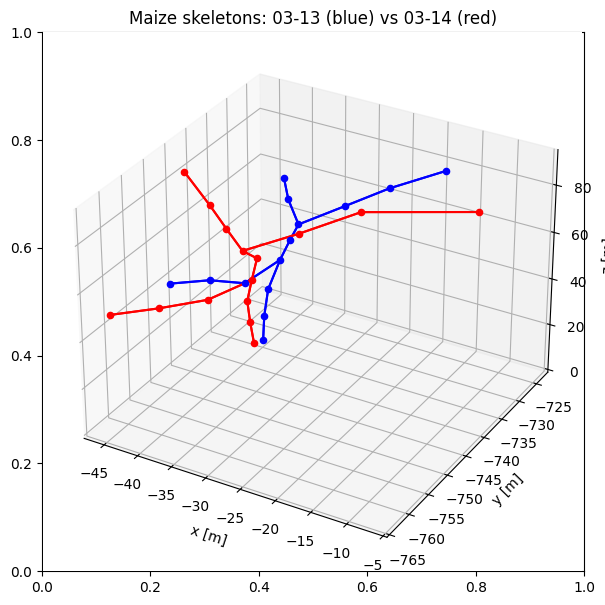

In [ ]:
import skeleton as skel
import visualize as vis
import matplotlib.pyplot as plt
import numpy as np

DATA = '/content/plantreg/data/maize'
S1 = skel.Skeleton.read_graph(f'{DATA}/03-13.graph.txt')
S2 = skel.Skeleton.read_graph(f'{DATA}/03-14.graph.txt')
print(f'S1 (03-13): {S1.node_count} nodes, {S1.edge_count} edges')
print(f'S2 (03-14): {S2.node_count} nodes, {S2.edge_count} edges')

fh = plt.figure(figsize=(7, 7))
vis.plot_skeleton(fh, S1, 'b')
vis.plot_skeleton(fh, S2, 'r')
ax = fh.gca()  # 3D axes already created by vis.plot_skeleton
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]'); ax.set_zlabel('z [m]')
plt.title('Maize skeletons: 03-13 (blue) vs 03-14 (red)')
plt.show()

## Step 1 — Skeleton matching (HMM correspondence estimation) / ステップ1: スケルトン対応付け

The authors formulate node correspondence between two skeletons as a hidden Markov model over potential node matches (with a “not matched” state), using emission costs from node-degree difference and Euclidean distance (`weight_e = 0.01`, `match_ends_to_ends = True`, exactly as in `demo/run_skeleton_matching.py`), solved with Viterbi. The output is an M×2 array of node-index correspondences (−1 = unmatched/virtual node).

We then compare against the authors' shipped reference file `03-13-03-14.corres.txt` (shown raw; it is 19 bytes).

著者のHMM（Viterbi）によるスケルトン対応付けを、デモと同じパラメータで実行し、同梱の参照ファイルと比較します。

In [ ]:
import skeleton_matching as skm

match_params = {'weight_e': 0.01,
                'match_ends_to_ends': True,
                'use_labels': False,
                'label_penalty': 1,
                'debug': False}

t0 = time.time()
corres = skm.skeleton_matching(S1, S2, match_params)
print(f'matching took {time.time()-t0:.2f} s')
print('correspondence array shape:', corres.shape)
print('estimated correspondences (S1 node -> S2 node):')
print(corres)

with open(f'{DATA}/03-13-03-14.corres.txt') as f:
    ref_raw = f.read()
print('--- authors\' shipped corres.txt (raw) ---')
print(ref_raw)

Computing matches.
HMM: Computing Transition and Emission probabilities


matching took 0.35 s
correspondence array shape: (9, 2)
estimated correspondences (S1 node -> S2 node):
[[ 5  3]
 [ 4  4]
 [ 0  0]
 [ 3  5]
 [ 2  1]
 [ 1  2]
 [10  8]
 [11  7]
 [ 9  6]]
--- authors' shipped corres.txt (raw) ---
5 3
4 4
0 0
3 5
2 1


## Step 2 — Iterative non-rigid registration / ステップ2: 反復非剛体レジストレーション

Registration parameters (a 4×4 affine transform per skeleton node) are estimated by minimizing a weighted energy (correspondence + rotation-orthogonality + neighbor regularization) with Gauss-Newton and a Cauchy robust kernel, alternating with re-matching over `num_iter = 5` outer iterations — exactly the parameters of `demo/run_iterative_registration.py` (`w_rot=100, w_reg=100, w_corresp=1, w_fix=1, cauchy param 2, 20 inner iterations`). The only adaptation: `visualize: False` so no interactive figure blocks execution; we render our own static figure.

The resulting registered source skeleton (black) should align with the target skeleton (red).

著者のデモと同じパラメータで「対応付け⇄レジストレーション」の反復を実行します（図の対話表示のみ無効化）。黒＝登録後のソーススケルトン、赤＝ターゲット。

-------------------- Global Iteration 0 --------------------------
Computing matches.
HMM: Computing Transition and Emission probabilities


Computing registration params.


Exiting optimization.
Total error =  [[0.08212197]]
Registration error for skeleton nodes =  0.007434901010635043
-------------------- Global Iteration 1 --------------------------
Computing matches.
HMM: Computing Transition and Emission probabilities


Computing registration params.


Exiting optimization.
Total error =  [[0.08631768]]
Registration error for skeleton nodes =  0.007247162107469479
-------------------- Global Iteration 2 --------------------------
Computing matches.
HMM: Computing Transition and Emission probabilities


Computing registration params.


Exiting optimization.
Total error =  [[0.08631762]]
Registration error for skeleton nodes =  0.007247161054727254
iterative registration took 6.60 s
final correspondences: (10, 2)


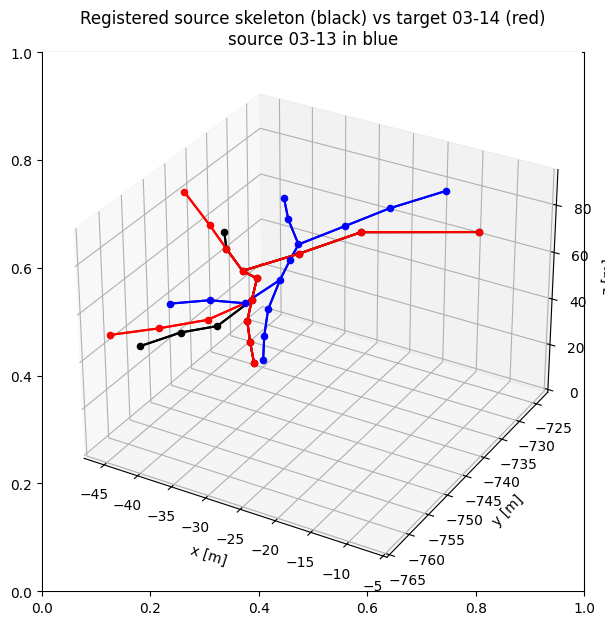

In [ ]:
import iterative_registration as itr
import non_rigid_registration as nrr

reg_params = {'num_iter': 20,
              'w_rot': 100,
              'w_reg': 100,
              'w_corresp': 1,
              'w_fix': 1,
              'fix_idx': [],
              'R_fix': [np.eye(3)],
              't_fix': [np.zeros((3, 1))],
              'use_robust_kernel': True,
              'robust_kernel_type': 'cauchy',
              'robust_kernel_param': 2,
              'debug': False}
params = {'num_iter': 5,
          'visualize': False,   # adaptation: suppress interactive demo figures
          'match_params': match_params,
          'reg_params': reg_params}

t0 = time.time()
T12, corres_it = itr.iterative_registration(S1, S2, params)
print(f'iterative registration took {time.time()-t0:.2f} s')
print('final correspondences:', corres_it.shape)

S2_hat = nrr.apply_registration_params_to_skeleton(S1, T12)
fh = plt.figure(figsize=(7, 7))
vis.plot_skeleton(fh, S1, 'b')
vis.plot_skeleton(fh, S2_hat, 'k')
vis.plot_skeleton(fh, S2, 'r')
ax = fh.gca()  # 3D axes already created by vis.plot_skeleton
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]'); ax.set_zlabel('z [m]')
plt.title('Registered source skeleton (black) vs target 03-14 (red)\nsource 03-13 in blue')
plt.show()

## Step 3 — Validate against the authors' shipped reference / ステップ3: 同梱参照出力との検証

The repository ships the authors' own registration result `03-13-03-14.reg.npy` (one 4×4 affine matrix per source-skeleton node). We compare our computed per-node transforms against it: Frobenius norm of the matrix difference and the translation-vector difference per node, plus summary statistics. Small nonzero differences are expected from solver tolerances; large ones would indicate our run diverged from the authors' procedure.

著者同梱の `reg.npy`（ノードごとの4×4アフィン行列）と、本実行で求めたT12を数値比較します。

In [ ]:
import pandas as pd

T_ref = np.load(f'{DATA}/03-13-03-14.reg.npy')
print('reference reg.npy shape:', T_ref.shape)
T_ours = np.stack(T12)
assert T_ours.shape == T_ref.shape, f'shape mismatch: ours {T_ours.shape} vs ref {T_ref.shape}'

diff_frob = np.linalg.norm(T_ours - T_ref, axis=(1, 2))
diff_t = np.linalg.norm(T_ours[:, :3, 3] - T_ref[:, :3, 3], axis=1)

summary = pd.DataFrame({
    'mean': [diff_frob.mean(), diff_t.mean()],
    'max':  [diff_frob.max(),  diff_t.max()],
}, index=['Frobenius ||T_ours - T_ref||', '||t_ours - t_ref|| [m]'])
print(summary.round(6))

per_node = pd.DataFrame({'node': np.arange(len(diff_frob)),
                         'frobenius_diff': diff_frob,
                         'translation_diff_m': diff_t})
per_node.to_csv('/content/t12_comparison_per_node.csv', index=False)
print('saved /content/t12_comparison_per_node.csv')

reference reg.npy shape: (14, 4, 4)
                                  mean       max
Frobenius ||T_ours - T_ref||  0.000036  0.000036
||t_ours - t_ref|| [m]        0.000036  0.000036
saved /content/t12_comparison_per_node.csv


## Step 4 — Deform the full point cloud / ステップ4: 点群の変形

Following `demo/run_pointcloud_deformation.py`: the 03-13 scan (`.xyz`, ~10 MB) is downsampled by the authors' factor 3, and every point is transformed by blending the affine transforms of its nearest skeleton node and the adjacent node the point projects onto (weighted linear blend — paper §cloud deformation / flow phase 5). We use the authors' `deform_pointcloud` unchanged and time the loop. The 03-14 target cloud is downsampled only for the overlap plot.

著者のコードをそのまま使って、03-13の点群を03-14へ変形します（著者のダウンサンプル係数3）。処理時間を計測します。

In [ ]:
import pointcloud as pcd

P1 = pcd.load_pointcloud(f'{DATA}/03-13.xyz')
P2 = pcd.load_pointcloud(f'{DATA}/03-14.xyz')
print(f'P1 (03-13): {P1.shape[0]} points, P2 (03-14): {P2.shape[0]} points')

DS = 3  # authors' demo downsampling factor
P1_ds = pcd.downsample_pointcloud(P1, DS)
P2_ds = pcd.downsample_pointcloud(P2, DS)
print(f'downsampled by {DS}: P1_ds {P1_ds.shape[0]} pts, P2_ds {P2_ds.shape[0]} pts')

t0 = time.time()
P1_deformed = pcd.deform_pointcloud(P1_ds, T12, corres_it, S1, S2)
t_def = time.time() - t0
print(f'point-cloud deformation took {t_def:.1f} s for {P1_ds.shape[0]} points')

P1 (03-13): 338874 points, P2 (03-14): 415666 points
downsampled by 3: P1_ds 112958 pts, P2_ds 138556 pts


point-cloud deformation took 8.1 s for 112958 points


## Step 5 — Registration quality / ステップ5: 登録結果の確認

Two checks, both computed here (not author figures):
1. **3D overlay** of the deformed 03-13 cloud (blue) on the target 03-14 cloud (red) — growth regions appear as red-only areas; well-overlapping tissue appears dark/purple-ish.
2. **Nearest-neighbor distance** from each deformed source point to the target cloud (computed on the downsampled clouds with a KD-tree), as a compact plausibility metric. This notebook-added metric is a heuristic, not a paper-reported value.

Results are exported to CSV.

変形後の点群（青）をターゲット（赤）に重ねて表示し、近傍距離の統計（このノートブックで追加した簡易指標）をCSV保存します。

Nearest-neighbor distance to target cloud (downsampled clouds):
                     mean_m  median_m   p90_m
before registration  4.9288     4.828  8.8404
after registration   0.9020     0.753  1.8160


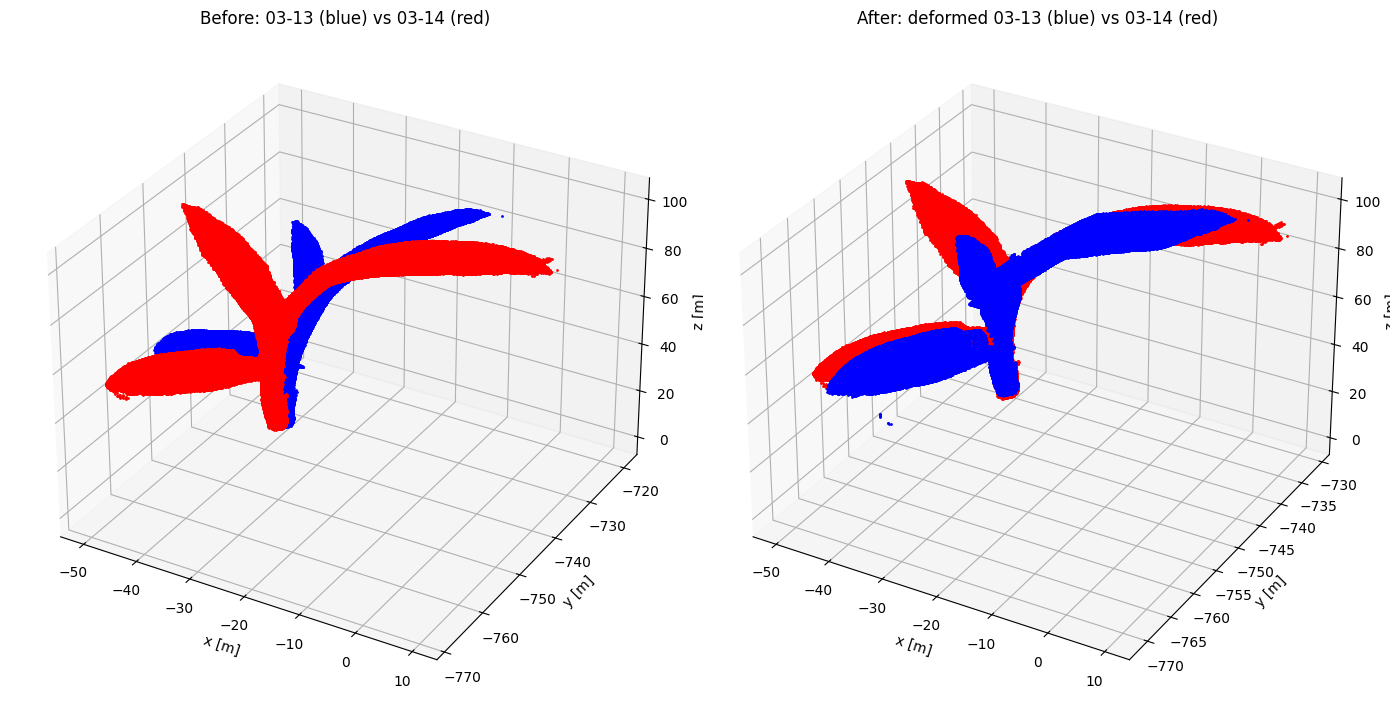

saved /content/nn_distance_stats.csv and /content/t12_comparison_per_node.csv


In [ ]:
from scipy.spatial import cKDTree

tree = cKDTree(P2_ds)
d_nn, _ = tree.query(P1_deformed, k=1)
d_nn_before, _ = tree.query(P1_ds, k=1)

nn_stats = pd.DataFrame({
    'mean_m':  [d_nn_before.mean(), d_nn.mean()],
    'median_m':[np.median(d_nn_before), np.median(d_nn)],
    'p90_m':   [np.percentile(d_nn_before, 90), np.percentile(d_nn, 90)],
}, index=['before registration', 'after registration'])
print('Nearest-neighbor distance to target cloud (downsampled clouds):')
print(nn_stats.round(4))
nn_stats.to_csv('/content/nn_distance_stats.csv')

fig = plt.figure(figsize=(14, 7))
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter3D(P2_ds[:,0], P2_ds[:,1], P2_ds[:,2], '.', color='r', s=1, depthshade=False)
ax1.scatter3D(P1_ds[:,0], P1_ds[:,1], P1_ds[:,2], '.', color='b', s=1, depthshade=False)
ax1.set_title('Before: 03-13 (blue) vs 03-14 (red)')
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter3D(P2_ds[:,0], P2_ds[:,1], P2_ds[:,2], '.', color='r', s=1, depthshade=False)
ax2.scatter3D(P1_deformed[:,0], P1_deformed[:,1], P1_deformed[:,2], '.', color='b', s=1, depthshade=False)
ax2.set_title('After: deformed 03-13 (blue) vs 03-14 (red)')
for ax in (ax1, ax2):
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]'); ax.set_zlabel('z [m]')
plt.tight_layout(); plt.show()
print('saved /content/nn_distance_stats.csv and /content/t12_comparison_per_node.csv')

## Interpretation & references / 結果の解釈と参照

**What was executed:** the authors' HMM skeleton matching, iterative Gauss-Newton non-rigid registration, and skeleton-driven point-cloud deformation (paper phases 3–5) on one maize scan pair, with the authors' code and parameters from the pinned commit. Registration quality is quantified by (a) agreement of our per-node transforms with the authors' shipped `reg.npy` and (b) the reduction in nearest-neighbor distance to the target cloud after deformation.

**Limitations:** one scan pair only; segmentation (SVM) and skeleton extraction (SOM) stages start from the authors' pre-computed skeletons, so segmentation errors are not exercised; the NN-distance metric is a notebook-added heuristic, not a paper metric; the single example does not verify dataset-level results (~3 mm reported accuracy vs ~35 mm for rigid ICP).

**実行内容と限界（日本語）:** 著者コード・パラメータをピン留めコミットからそのまま使い、トウモロコシ1組の連続スキャンでHMM対応付け→非剛体レジストレーション→点群変形を実行しました。セグメンテーション/スケルトン抽出は著者提供の結果を使用しており、形質トラッキング・補間は対象外です。本例単体で論文のデータセット全体の精度（剛体ICP約35mmに対して約3mm）を検証するものではありません。

**References**
- Paper: [DOI 10.1371/journal.pone.0247243](https://doi.org/10.1371/journal.pone.0247243), PLoS ONE 16(2): e0247243 (2021), CC BY 4.0.
- Code: PRBonn/4d_plant_registration @ `d1857ed374ce2d20e016e09fb24d9dbf4e6c396a`, MIT License (files used: `skeleton.py`, `skeleton_matching.py`, `non_rigid_registration.py`, `iterative_registration.py`, `pointcloud.py`, `helperfunctions.py`, `robust_functions.py`, `visualize.py`; demos 2–5).
- Demo data: `data/maize/03-13*`, `03-14*` from the same pinned commit; extended dataset at https://www.ipb.uni-bonn.de/data/4d-plant-registration/.

In [ ]:
print('Run complete:', time.strftime('%Y-%m-%d %H:%M:%S UTC', time.gmtime()))
print('Artifacts in /content: t12_comparison_per_node.csv, nn_distance_stats.csv')

Run complete: 2026-10-01 07:40:43 UTC
Artifacts in /content: t12_comparison_per_node.csv, nn_distance_stats.csv
